In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

np.set_printoptions(precision=3, suppress=True)
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import scale, StandardScaler

# Predict Nationality from Names
- In this exercise, we are going to get names of the European Parliment members from European Parliment website.
- We will use `xml.etree.ElementTree` library for turning an xml file in string format into xml file
- We will use `requests` library to request an`xml` file from a webpage

  - XML documents have sections, called elements, defined by a beginning and an ending tag. A tag is a markup construct that begins with < and ends with >. The characters between the start-tag and end-tag, if there are any, are the element's content. Elements can contain markup, including other elements, which are called "child elements".
  - The largest, top-level element is called the root, which contains all other elements.
  - Attributes are name–value pair that exist within a start-tag or empty-element tag. An XML attribute can only have a single value and each attribute can appear at most once on each element.
  

In [2]:
import xml.etree.ElementTree as ET

In [3]:
import requests

- `fromstring()` parses XML from a string directly into an `Element`, which is the root element of the parsed tree.

- We are now turning the xml string file into a list

Instead of XML can I just use a dataframe from cleaned CSV?

In [4]:
df = pd.read_csv('EU Parliament Members.csv')
df

,fullName,country,politicalGroup,id,nationalPoliticalGroup
0,Mika AALTOLA,Finland,Group of the European People's Party (Christia...,256810,Kansallinen Kokoomus
1,Maravillas ABADÍA JOVER,Spain,Group of the European People's Party (Christia...,257043,Partido Popular
2,Magdalena ADAMOWICZ,Poland,Group of the European People's Party (Christia...,197490,Independent
3,Georgios AFTIAS,Greece,Group of the European People's Party (Christia...,256820,Nea Demokratia
4,Oihane AGIRREGOITIA MARTÍNEZ,Spain,Renew Europe Group,256987,Partido Nacionalista Vasco
...,...,...,...,...,...
714,Nicola ZINGARETTI,Italy,Group of the Progressive Alliance of Socialist...,28419,Partito Democratico
715,Kosma ZŁOTOWSKI,Poland,European Conservatives and Reformists Group,124884,Prawo i Sprawiedliwość
716,Juan Ignacio ZOIDO ÁLVAREZ,Spain,Group of the European People's Party (Christia...,197621,Partido Popular
717,Željana ZOVKO,Croatia,Group of the European People's Party (Christia...,185341,Hrvatska demokratska zajednica


# EDA

- Create a bar graph showing the ratio of nationalities in the European parliament

Value Counts:
country
Germany        96
France         81
Italy          76
Spain          60
Poland         53
Romania        33
Netherlands    31
Belgium        22
Greece         21
Sweden         21
Czechia        21
Hungary        21
Portugal       21
Austria        20
Bulgaria       17
Denmark        15
Slovakia       15
Finland        15
Ireland        14
Croatia        12
Lithuania      11
Slovenia        9
Latvia          9
Estonia         7
Luxembourg      6
Cyprus          6
Malta           6
Name: count, dtype: int64


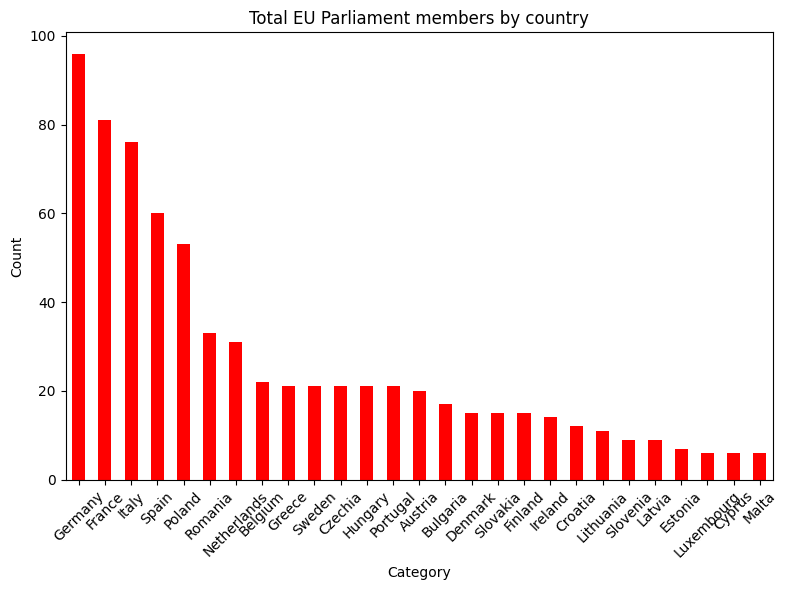

In [7]:
# Calculate value counts
counts = df['country'].value_counts()
print("Value Counts:")
print(counts)

# Create bar chart
plt.figure(figsize=(8, 6)) # Optional: adjust figure size
counts.plot(kind='bar', color='red')
plt.title('Total EU Parliament members by country')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45) # Keeps x-axis labels horizontal
plt.tight_layout() # Adjust layout to make room for labels
plt.show()

- print the value counts of the members per country

In [8]:
counts

country
Germany        96
France         81
Italy          76
Spain          60
Poland         53
Romania        33
Netherlands    31
Belgium        22
Greece         21
Sweden         21
Czechia        21
Hungary        21
Portugal       21
Austria        20
Bulgaria       17
Denmark        15
Slovakia       15
Finland        15
Ireland        14
Croatia        12
Lithuania      11
Slovenia        9
Latvia          9
Estonia         7
Luxembourg      6
Cyprus          6
Malta           6
Name: count, dtype: int64

- Get the names of the first 8 countries with the largest number of meps

In [12]:
# Create new dataframe with only the top 8 largest countries by total members
top_8 = df['country'].value_counts().nlargest(8).index
top_8_df = df[df['country'].isin(top_8)].copy()

In [13]:
top_8_df

,fullName,country,politicalGroup,id,nationalPoliticalGroup
1,Maravillas ABADÍA JOVER,Spain,Group of the European People's Party (Christia...,257043,Partido Popular
2,Magdalena ADAMOWICZ,Poland,Group of the European People's Party (Christia...,197490,Independent
4,Oihane AGIRREGOITIA MARTÍNEZ,Spain,Renew Europe Group,256987,Partido Nacionalista Vasco
8,Grégory ALLIONE,France,Renew Europe Group,256869,Renaissance
11,Christine ANDERSON,Germany,Europe of Sovereign Nations Group,197475,Alternative für Deutschland
...,...,...,...,...,...
711,Bogdan Andrzej ZDROJEWSKI,Poland,Group of the European People's Party (Christia...,124893,Koalicja Obywatelska
712,Auke ZIJLSTRA,Netherlands,Patriots for Europe Group,103246,Partij voor de Vrijheid
714,Nicola ZINGARETTI,Italy,Group of the Progressive Alliance of Socialist...,28419,Partito Democratico
715,Kosma ZŁOTOWSKI,Poland,European Conservatives and Reformists Group,124884,Prawo i Sprawiedliwość


# Predictions

- create a data with the parliament members in the first eight countries
- split data into test and train datasets

- create a pipeline of `countvectorizer` and `logisticregressioncv`
- report the cross validation scores

- Repeat the same procedure, with vectorizer having the parameter of analyzer="char_wb"

 - analyzer{‘word’, ‘char’, ‘char_wb’} or callable, default=’word’ Whether the feature should be made of word n-gram or character n-grams. Option ‘char_wb’ creates character n-grams only from text inside word boundaries; n-grams at the edges of words are padded with space.

- print the top 20 most important and least important n-grams

In [96]:
def plot_important_features(coef, feature_names, top_n=20, ax=None, rotation=60):
    if ax is None:
        ax = plt.gca()
    inds = np.argsort(coef)
    low = inds[:top_n]
    high = inds[-top_n:]
    important = np.hstack([low, high])
    myrange = range(len(important))
    colors = ['red'] * top_n + ['blue'] * top_n
    
    ax.bar(myrange, coef[important], color=colors)
    ax.set_xticks(myrange)
    ax.set_xticklabels(feature_names[important], rotation=rotation, ha="right")
    ax.set_xlim(-.7, 2 * top_n)
    ax.set_frame_on(False)

- Now make a gridsearch over logistic regression, countvectorizer n-grams, min_df and normalizer